# AOS Correlation Explorer

Search a nightly AOS summary table for correlations between **delivered image
quality** and **mechanical / thermal / AOS-state** variables that the active
optics control loop may be missing.

**Physics framing (see project notes):**

- *Ultimate targets* we want to reduce: `psf_fwhm` and `psf_ellipticity_median`.
- `donut_blur_fwhm` is dominated by **atmospheric + dome seeing**, which the AOS
  system cannot control. Together with `dimm` and `airmass` it is treated as a
  **confound** to be removed, not a target.
- `aos_fwhm` is the residual the AOS loop is actively trying to null.

Plain correlation would just rediscover "seeing drives PSF". The interesting
signal is **partial correlation**: after removing the atmospheric component,
which mechanical/thermal variables *still* track PSF FWHM and ellipticity?
Those are candidate missed correlations worth acting on.

Input is one parquet produced by `nightly_tablemaker.ipynb`.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Parameters ---
PARQUET = "../parquet_files/nightly_aos_table_20260529_summit.parquet"

raw = pd.read_parquet(PARQUET)
print("rows:", len(raw), " cols:", raw.shape[1])

INFO:numexpr.utils:Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.


INFO:numexpr.utils:Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


INFO:numexpr.utils:NumExpr defaulting to 16 threads.


rows: 902  cols: 88


## 1. Build a scalar feature table

The parquet has list-valued columns (`zernikes_fwhm`, `vmodes`, `dof_state`, ...).
Correlation needs scalars, so we expand the physically-interpretable vectors:

- `zernikes_fwhm` (25) &rarr; `zkfwhm_z4 ... zkfwhm_z28`: each Zernike's quadrature
  contribution to the PSF FWHM, in arcsec.
- `vmodes` (12) &rarr; `vmode_1 ... vmode_12`: the AOS control eigen-modes.

`dof_state` / `lut_state` (50 raw actuator DOFs) are left out of the first pass;
`vmodes` is their physically-meaningful low-dimensional projection.

In [2]:
def expand_vector(df, col, prefix, start=1):
    """Expand a fixed-length list column into scalar columns prefix{start..}."""
    sub = df[col].dropna()
    if len(sub) == 0:
        return pd.DataFrame(index=df.index)
    n = len(sub.iloc[0])
    mat = np.full((len(df), n), np.nan)
    mask = df[col].notna().values
    mat[mask] = np.vstack(sub.values)
    names = [f"{prefix}{i}" for i in range(start, start + n)]
    return pd.DataFrame(mat, columns=names, index=df.index)

# zernikes_fwhm is z4..z28 -> label by Noll index
zk = expand_vector(raw, "zernikes_fwhm", "zkfwhm_z", start=4)
vm = expand_vector(raw, "vmodes", "vmode_", start=1)

feat = pd.concat([raw.select_dtypes(include="number"), zk, vm], axis=1)
feat = feat.loc[:, ~feat.columns.duplicated()]
print("feature columns:", feat.shape[1])

feature columns: 95


## 2. Define targets, confounds, and candidate drivers

In [3]:
TARGETS = ["psf_fwhm", "fwhm_zenith_500nm", "psf_ellipticity_median"]

# Atmospheric / dome seeing: not AOS-controllable -> remove these.
CONFOUNDS = ["donut_blur_fwhm", "dimm", "airmass"]

# Everything mechanical / thermal / geometric / AOS-state is a candidate driver.
_exclude = set(TARGETS) | set(CONFOUNDS) | {
    "visit_id", "day_obs", "seq", "detector", "__index_level_0__",
    # other image-quality metrics, not drivers of the targets
    "psf_fwhm_min", "psf_fwhm_max", "psf_fwhm_05", "psf_fwhm_95",
    "psf_fwhm_95_05", "psf_fwhm_sigma", "psf_ellipticity_sigma",
    "psf_area", "psf_area_min", "psf_area_max", "aos_fwhm",
}
DRIVERS = [c for c in feat.columns
           if c not in _exclude and feat[c].notna().sum() > 50]
print(f"{len(DRIVERS)} candidate drivers")
print(DRIVERS)

74 candidate drivers
['air_temp', 'elevation', 'azimuth', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23', 'z24', 'z25', 'z26', 'rotation_angle', 'cam_air_temp', 'm2_air_temp', 'm1m3_air_temp', 'outside_temp', 'seq_num_corr', 'x_gradient', 'y_gradient', 'z_gradient', 'radial_gradient', 'm2_delta_t', 'dome_delta_t', 'cam_m1m3_delta_t', 'zkfwhm_z4', 'zkfwhm_z5', 'zkfwhm_z6', 'zkfwhm_z7', 'zkfwhm_z8', 'zkfwhm_z9', 'zkfwhm_z10', 'zkfwhm_z11', 'zkfwhm_z12', 'zkfwhm_z13', 'zkfwhm_z14', 'zkfwhm_z15', 'zkfwhm_z16', 'zkfwhm_z17', 'zkfwhm_z18', 'zkfwhm_z19', 'zkfwhm_z20', 'zkfwhm_z21', 'zkfwhm_z22', 'zkfwhm_z23', 'zkfwhm_z24', 'zkfwhm_z25', 'zkfwhm_z26', 'zkfwhm_z27', 'zkfwhm_z28', 'vmode_1', 'vmode_2', 'vmode_3', 'vmode_4', 'vmode_5', 'vmode_6', 'vmode_7', 'vmode_8', 'vmode_9', 'vmode_10', 'vmode_11', 'vmode_12']


## 3. Raw Spearman ranking

Spearman (rank) correlation is robust to outliers and monotonic non-linearity.
This first pass includes the confounds so we can *see* how dominant seeing is.

In [4]:
def ranked_corr(df, targets, drivers, method="spearman"):
    rows = []
    for t in targets:
        for d in drivers:
            s = df[[t, d]].dropna()
            if len(s) < 30 or s[d].std() == 0:
                continue
            if method == "spearman":
                r, p = stats.spearmanr(s[t], s[d])
            else:
                r, p = stats.pearsonr(s[t], s[d])
            rows.append((t, d, r, p, len(s)))
    out = pd.DataFrame(rows, columns=["target", "driver", "r", "p", "n"])
    out["abs_r"] = out["r"].abs()
    return out.sort_values("abs_r", ascending=False).reset_index(drop=True)

raw_rank = ranked_corr(feat, TARGETS, DRIVERS + CONFOUNDS)
print("Top 20 raw correlations (confounds included):")
raw_rank.head(20)

Top 20 raw correlations (confounds included):


,target,driver,r,p,n,abs_r
0,fwhm_zenith_500nm,donut_blur_fwhm,0.801430,4.065440e-203,902,0.801430
1,psf_fwhm,donut_blur_fwhm,0.677519,3.315829e-122,902,0.677519
2,fwhm_zenith_500nm,rotation_angle,0.654681,1.693831e-111,902,0.654681
3,fwhm_zenith_500nm,cam_m1m3_delta_t,0.643266,1.734226e-106,902,0.643266
4,fwhm_zenith_500nm,dimm,0.629128,4.484772e-96,861,0.629128
5,psf_fwhm,cam_m1m3_delta_t,0.616520,1.512201e-95,902,0.616520
6,fwhm_zenith_500nm,m1m3_air_temp,-0.596515,4.994425e-88,902,0.596515
7,fwhm_zenith_500nm,x_gradient,0.561703,3.884218e-76,902,0.561703
8,fwhm_zenith_500nm,z25,0.550593,1.243628e-72,902,0.550593
9,fwhm_zenith_500nm,zkfwhm_z25,0.550593,1.243628e-72,902,0.550593


## 4. Partial correlation &mdash; the key step

We residualize both the target and each driver against the confounds
(`donut_blur_fwhm`, `dimm`, `airmass`) via linear regression, then correlate the
residuals. This asks: *holding the atmosphere fixed, does this variable still
track the target?*

We report the partial correlation alongside the raw one. A driver whose raw
correlation is large but partial correlation collapses is just a seeing proxy.
A driver whose partial correlation stays strong is a genuine missed lever.

In [5]:
def residualize(y, X):
    """Return residuals of y regressed on X (with intercept). Rows with any NaN dropped upstream."""
    X1 = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    return y - X1 @ beta

def partial_corr_table(df, targets, drivers, confounds, method="spearman"):
    rows = []
    for t in targets:
        for d in drivers:
            cols = [t, d] + confounds
            s = df[cols].dropna()
            if len(s) < 30 or s[d].std() == 0:
                continue
            C = s[confounds].values
            ry = residualize(s[t].values, C)
            rd = residualize(s[d].values, C)
            if method == "spearman":
                pr, pp = stats.spearmanr(ry, rd)
                rr, _ = stats.spearmanr(s[t], s[d])
            else:
                pr, pp = stats.pearsonr(ry, rd)
                rr, _ = stats.pearsonr(s[t], s[d])
            rows.append((t, d, rr, pr, pp, len(s)))
    out = pd.DataFrame(rows, columns=["target", "driver", "raw_r", "partial_r", "p", "n"])
    out["abs_partial"] = out["partial_r"].abs()
    return out.sort_values("abs_partial", ascending=False).reset_index(drop=True)

pc = partial_corr_table(feat, TARGETS, DRIVERS, CONFOUNDS)
print("Top 25 partial correlations (atmosphere removed):")
pc.head(25)

Top 25 partial correlations (atmosphere removed):


,target,driver,raw_r,partial_r,p,n,abs_partial
0,psf_fwhm,m2_delta_t,0.490887,0.592799,7.981665e-83,861,0.592799
1,fwhm_zenith_500nm,m2_delta_t,0.139566,0.591975,1.524593e-82,861,0.591975
2,psf_fwhm,azimuth,0.332169,0.542221,5.755809e-67,861,0.542221
3,fwhm_zenith_500nm,azimuth,0.131665,0.532399,3.434847e-64,861,0.532399
4,psf_fwhm,vmode_3,-0.490589,-0.510142,3.155824e-58,861,0.510142
5,fwhm_zenith_500nm,vmode_3,-0.118122,-0.486057,2.976968e-52,861,0.486057
6,fwhm_zenith_500nm,dome_delta_t,0.233955,0.466833,8.169347e-48,861,0.466833
7,psf_fwhm,cam_m1m3_delta_t,0.599718,0.458059,7.012079e-46,861,0.458059
8,psf_fwhm,dome_delta_t,0.389783,0.454110,4.988819e-45,861,0.454110
9,fwhm_zenith_500nm,cam_m1m3_delta_t,0.628735,0.438382,9.608845e-42,861,0.438382


### Drivers that survive de-seeing

Sort by how much correlation *remains* after removing the atmosphere, and flag
drivers where the partial correlation stays high &mdash; these are the leads.

In [6]:
survivors = pc[(pc["abs_partial"] > 0.15) & (pc["p"] < 0.01)].copy()
survivors["shrinkage"] = 1 - survivors["abs_partial"] / survivors["raw_r"].abs().clip(lower=1e-6)
print(f"{len(survivors)} (target, driver) pairs with |partial r| > 0.15 and p < 0.01")
survivors[["target", "driver", "raw_r", "partial_r", "p", "n"]].head(30)

65 (target, driver) pairs with |partial r| > 0.15 and p < 0.01


,target,driver,raw_r,partial_r,p,n
0,psf_fwhm,m2_delta_t,0.490887,0.592799,7.981665e-83,861
1,fwhm_zenith_500nm,m2_delta_t,0.139566,0.591975,1.524593e-82,861
2,psf_fwhm,azimuth,0.332169,0.542221,5.755809e-67,861
3,fwhm_zenith_500nm,azimuth,0.131665,0.532399,3.434847e-64,861
4,psf_fwhm,vmode_3,-0.490589,-0.510142,3.155824e-58,861
5,fwhm_zenith_500nm,vmode_3,-0.118122,-0.486057,2.976968e-52,861
6,fwhm_zenith_500nm,dome_delta_t,0.233955,0.466833,8.169347e-48,861
7,psf_fwhm,cam_m1m3_delta_t,0.599718,0.458059,7.012079e-46,861
8,psf_fwhm,dome_delta_t,0.389783,0.454110,4.988819e-45,861
9,fwhm_zenith_500nm,cam_m1m3_delta_t,0.628735,0.438382,9.608845e-42,861


## 5. Diagnostic scatter plots for the strongest partial correlations

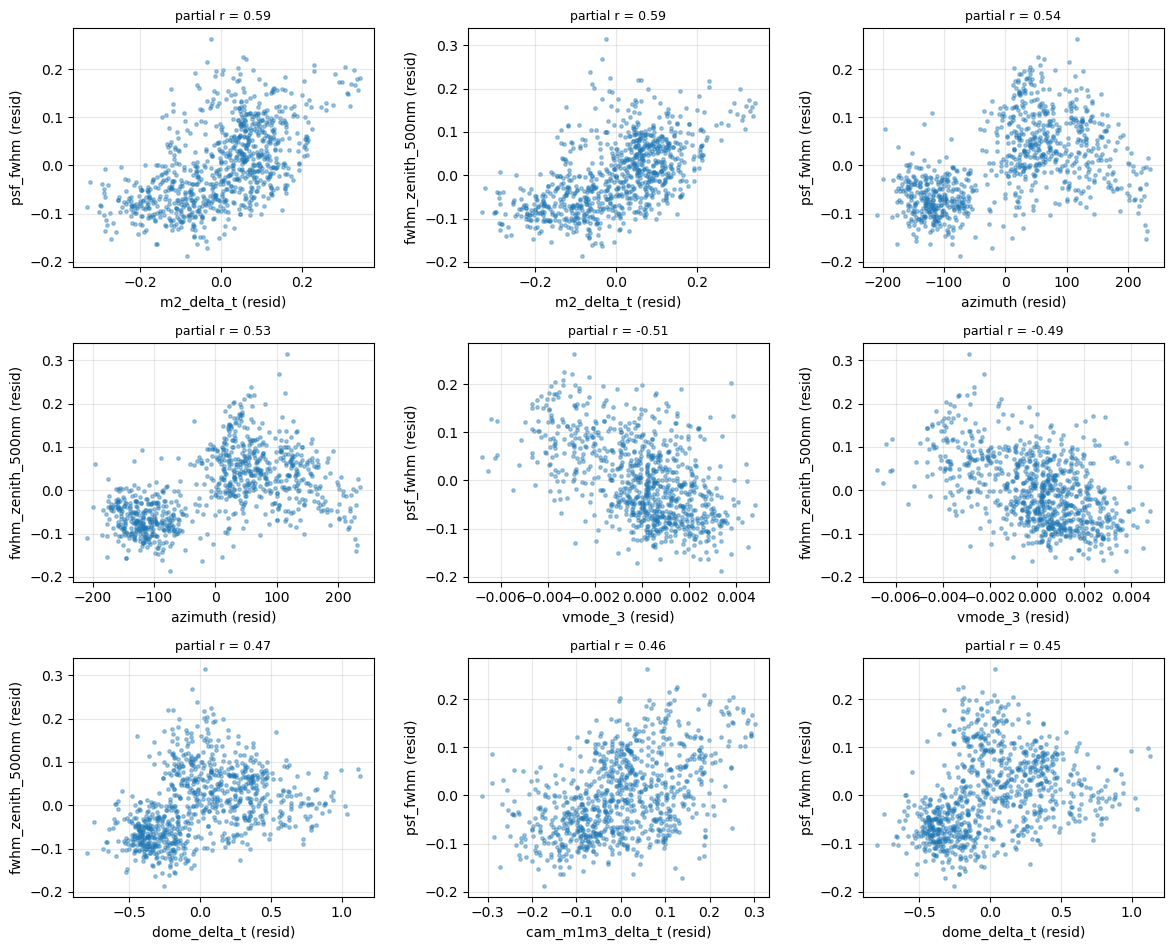

In [7]:
def scatter_partial(df, target, driver, confounds, ax):
    s = df[[target, driver] + confounds].dropna()
    C = s[confounds].values
    ry = residualize(s[target].values, C)
    rd = residualize(s[driver].values, C)
    ax.scatter(rd, ry, s=6, alpha=0.4)
    pr, _ = stats.spearmanr(ry, rd)
    ax.set_xlabel(f"{driver} (resid)")
    ax.set_ylabel(f"{target} (resid)")
    ax.set_title(f"partial r = {pr:.2f}", fontsize=9)
    ax.grid(alpha=0.3)

top = survivors.head(9)
if len(top):
    n = len(top)
    ncol = 3
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
    for ax, (_, r) in zip(np.atleast_1d(axes).ravel(), top.iterrows()):
        scatter_partial(feat, r["target"], r["driver"], CONFOUNDS, ax)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    fig.tight_layout()
else:
    print("No survivors to plot.")

## 6. Driver correlation heatmap

Many candidate drivers are themselves correlated (e.g. the temperature deltas,
the thermal gradients). This heatmap shows the driver&ndash;driver structure so a
cluster of correlated drivers isn't mistaken for independent leads.

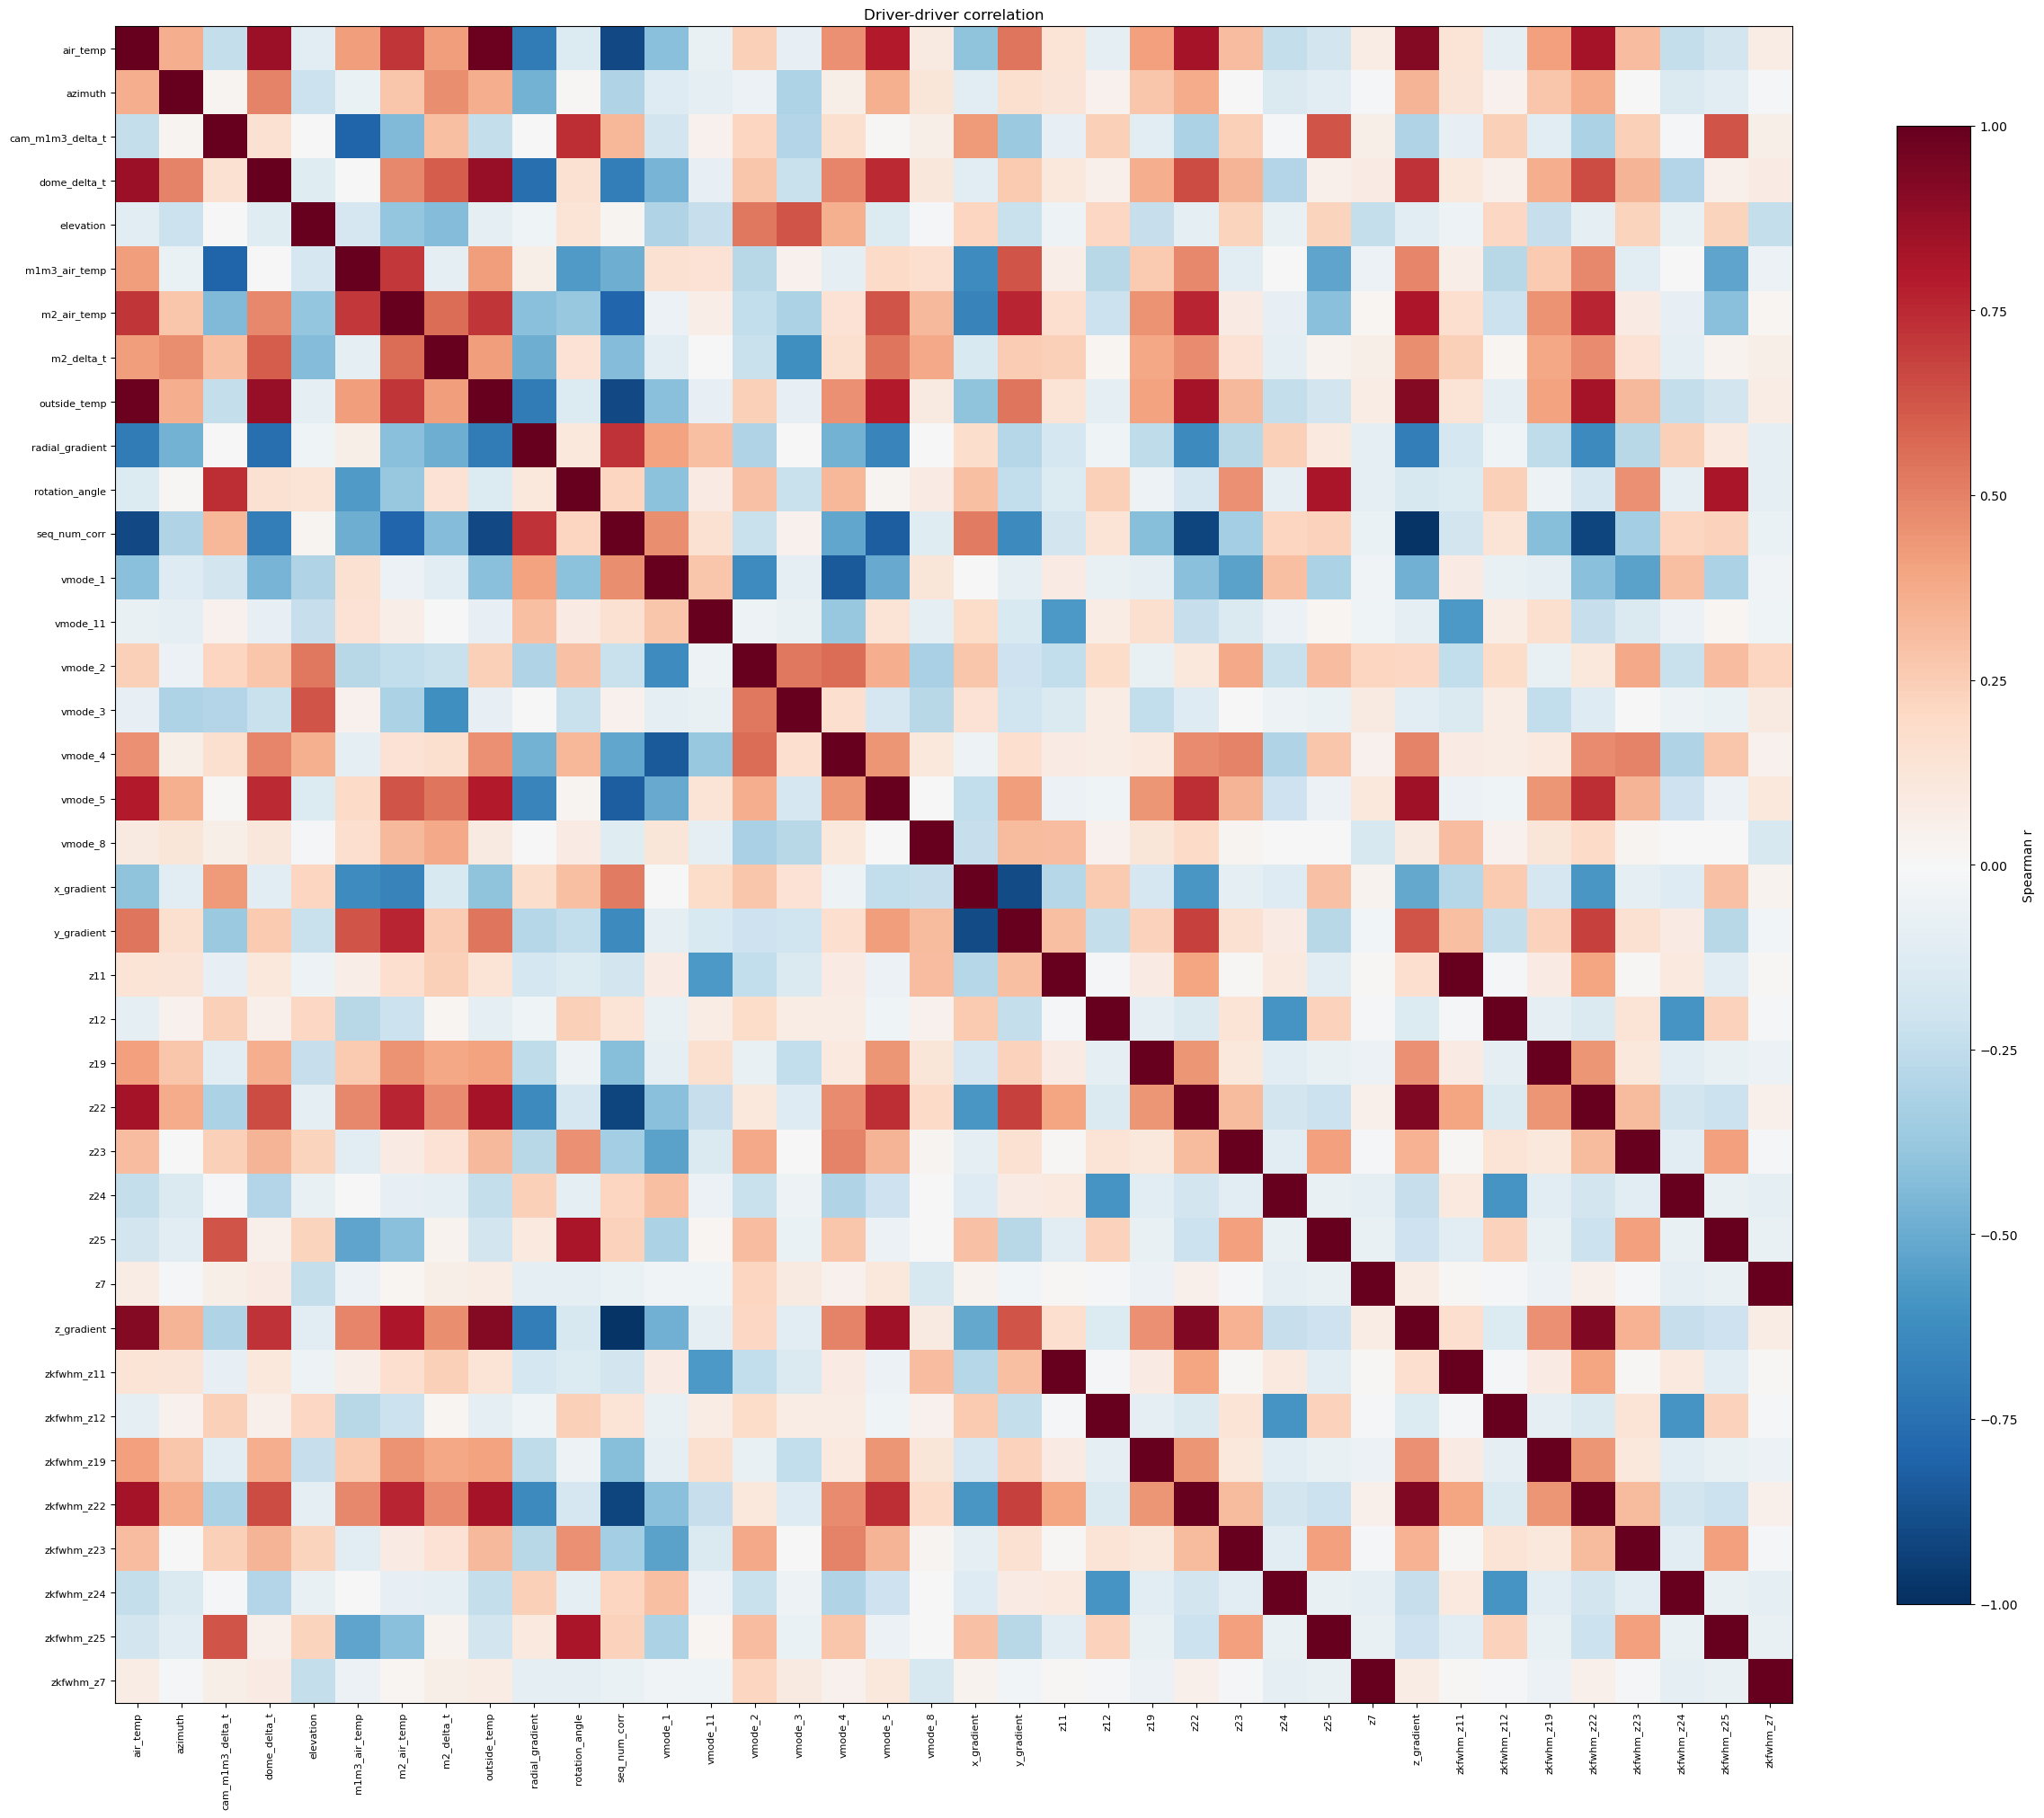

In [8]:
import numpy as np
sig_drivers = sorted(set(survivors["driver"]) | {
    "m2_delta_t", "dome_delta_t", "cam_m1m3_delta_t",
    "x_gradient", "y_gradient", "z_gradient", "radial_gradient",
    "elevation", "azimuth", "rotation_angle",
} & set(feat.columns))
cm = feat[sig_drivers].corr(method="spearman")
fig, ax = plt.subplots(figsize=(0.6 * len(sig_drivers) + 2, 0.6 * len(sig_drivers) + 1))
im = ax.imshow(cm.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(sig_drivers))); ax.set_xticklabels(sig_drivers, rotation=90, fontsize=8)
ax.set_yticks(range(len(sig_drivers))); ax.set_yticklabels(sig_drivers, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman r")
ax.set_title("Driver-driver correlation")
fig.tight_layout()

## 7. Notes / next steps

- If a strong partial correlation points at a variable **not yet in the parquet**
  (e.g. wind speed/direction, dome vent state, mount tracking error, individual
  M1M3 actuator forces), that is a signal to extend `nightly_tablemaker.ipynb`
  to add it, then re-run this explorer.
- Consider running across multiple nights to separate per-night atmospheric
  regimes from persistent mechanical/thermal effects.
- Ellipticity specifically may correlate with rotation angle / elevation
  (gravity-induced) or with astigmatic Zernikes (`zkfwhm_z5/z6`) &mdash; check whether
  the AOS is nulling those.